In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../results', exist_ok=True)
os.makedirs('../figures/final', exist_ok=True)

labels = pd.read_csv('../data/processed/engraftment_labels.csv')
print(f'Labels: {labels.shape}')
print(f'Cols: {labels.columns.tolist()}')

causal = pd.read_csv('../data/processed/causal/causal_effects.csv')
causal_feat = causal[['species', 'ace', 'significant']].rename(
    columns={'ace': 'causal_ace', 'significant': 'causal_sig'}
)
print(f'Causal effects: {causal_feat.shape}')

growth = pd.read_csv('../data/processed/micom_growth_results.csv')
resource_score = (
    growth.groupby('species')['growth_rate']
    .mean().rename('resource_accessibility').reset_index()
)
print(f'Resource accessibility: {len(resource_score)} species')

exchanges  = pd.read_csv('../data/processed/micom_exchange_results.csv')
secretions = exchanges[exchanges['flux'] > 0]
crossfeed  = (
    secretions.groupby('species')['flux']
    .sum().rename('crossfeeding_synergy').reset_index()
)
max_f = crossfeed['crossfeeding_synergy'].max()
if max_f > 0:
    crossfeed['crossfeeding_synergy'] /= max_f
print(f'Cross-feeding synergy: {len(crossfeed)} species')

scfa = pd.read_csv('../data/processed/micom_scfa_scores.csv')
SCFA_COLS = [c for c in [
    'butyrate_flux', 'propionate_flux', 'acetate_flux',
    'lactate_flux',  'succinate_flux',  'formate_flux',
    'therapeutic_score'
] if c in scfa.columns]
print(f'SCFA features: {SCFA_COLS}')

keystones = {}
networks  = {}
for cond in ['CD', 'UC', 'Healthy']:
    keystones[cond] = pd.read_csv(f'../results/networks/keystones_{cond}.csv')
    networks[cond]  = nx.read_gexf(f'../results/networks/{cond}_network.gexf')
print(f'Networks loaded: CD={networks["CD"].number_of_nodes()} nodes, '
      f'UC={networks["UC"].number_of_nodes()}, '
      f'Healthy={networks["Healthy"].number_of_nodes()}')

smillie = pd.read_csv('../data/processed/smillie_engraftment_auc.csv')

train_labels = labels[labels['split'] == 'train']
pod_prob = (
    train_labels.groupby('species')['engrafted']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'podlesny_prob', 'count': 'n_obs'})
    .reset_index()
)
pod_prob = pod_prob[pod_prob['n_obs'] >= 3]
pod_prob = pod_prob.merge(
    smillie[['species', 'smillie_engraftment_prob']],
    on='species', how='left'
)
pod_prob['causal_engraftment_prob'] = np.where(
    pod_prob['smillie_engraftment_prob'].notna(),
    0.6 * pod_prob['podlesny_prob'] + 0.4 * pod_prob['smillie_engraftment_prob'],
    pod_prob['podlesny_prob']
)
cep_df = pod_prob[['species', 'causal_engraftment_prob']].copy()
print(f'Causal engraftment prob: {len(cep_df)} species')

print('\nAll data loaded successfully')

Labels: (10951, 10)
Cols: ['case', 'donor_id', 'post_id', 'species', 'donor_abundance', 'post_abundance', 'engrafted', 'disease', 'days_post_fmt', 'split']
Causal effects: (132, 3)
Resource accessibility: 81 species
Cross-feeding synergy: 82 species
SCFA features: ['butyrate_flux', 'propionate_flux', 'acetate_flux', 'lactate_flux', 'succinate_flux', 'formate_flux', 'therapeutic_score']
Networks loaded: CD=87 nodes, UC=87, Healthy=87
Causal engraftment prob: 208 species

All data loaded successfully


In [2]:
def keystone_conflict(sp, networks, keystones, top_n=10):
    scores = []
    for cond in ['CD', 'UC', 'Healthy']:
        G  = networks[cond]
        ks = keystones[cond].head(top_n)['species'].tolist()
        if sp not in G:
            scores.append(0.0); continue
        nbrs = list(G.neighbors(sp))
        if not nbrs:
            scores.append(0.0); continue
        conflict = [n for n in nbrs
                    if n in ks and G[sp][n].get('interaction') == 'competition']
        scores.append(len(conflict) / len(nbrs))
    return np.mean(scores)


def niche_overlap(sp, networks):
    scores = []
    for cond in ['CD', 'UC', 'Healthy']:
        G = networks[cond]
        if sp not in G:
            scores.append(0.0); continue
        w = [d['weight'] for _, _, d in G.edges(sp, data=True)
             if d.get('interaction') == 'mutualism']
        scores.append(np.mean(w) if w else 0.0)
    return np.mean(scores)


species_list = cep_df['species'].tolist()
print(f'Computing ecological scores for {len(species_list)} species...')

eco_rows = []
for sp in species_list:
    eco_rows.append({
        'species':                sp,
        'keystone_conflict_mean': keystone_conflict(sp, networks, keystones),
        'niche_overlap_mean':     niche_overlap(sp, networks),
    })

eco_df = pd.DataFrame(eco_rows)
print(f'Done.')
print(f'Keystone conflict mean: {eco_df["keystone_conflict_mean"].mean():.4f}')
print(f'Niche overlap mean:     {eco_df["niche_overlap_mean"].mean():.4f}')

Computing ecological scores for 208 species...
Done.
Keystone conflict mean: 0.0288
Niche overlap mean:     0.0736


In [3]:
from sklearn.preprocessing import MinMaxScaler

df = labels.copy()

for src, key_col in [
    (cep_df,                                          'species'),
    (eco_df,                                          'species'),
    (resource_score,                                  'species'),
    (crossfeed[['species', 'crossfeeding_synergy']],  'species'),
    (causal_feat,                                     'species'),
    (scfa[['species'] + SCFA_COLS],                   'species'),
]:
    df = df.merge(src, on=key_col, how='left')

df = df.fillna(0)

print(f'Merged shape: {df.shape}')
print(f'Missing values: {df.isna().sum().sum()}  (should be 0)')

NORM_COLS = [c for c in [
    'causal_engraftment_prob', 'keystone_conflict_mean',
    'niche_overlap_mean',      'resource_accessibility',
    'crossfeeding_synergy',    'causal_ace'
] + SCFA_COLS if c in df.columns and c != 'therapeutic_score']

scaler        = MinMaxScaler()
df[NORM_COLS] = scaler.fit_transform(df[NORM_COLS])

df['keystone_conflict_mean'] = 1 - df['keystone_conflict_mean']
df['niche_overlap_mean']     = 1 - df['niche_overlap_mean']

ALL_FEATURES = [c for c in [
    'causal_engraftment_prob', 'keystone_conflict_mean',
    'niche_overlap_mean',      'resource_accessibility',
    'crossfeeding_synergy',    'causal_ace', 'causal_sig',
    'donor_abundance'
] + SCFA_COLS if c in df.columns]

print(f'\nAll features ({len(ALL_FEATURES)}):')
print(ALL_FEATURES)

Merged shape: (10951, 24)
Missing values: 0  (should be 0)

All features (15):
['causal_engraftment_prob', 'keystone_conflict_mean', 'niche_overlap_mean', 'resource_accessibility', 'crossfeeding_synergy', 'causal_ace', 'causal_sig', 'donor_abundance', 'butyrate_flux', 'propionate_flux', 'acetate_flux', 'lactate_flux', 'succinate_flux', 'formate_flux', 'therapeutic_score']


In [4]:
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, classification_report,
    precision_score, recall_score, f1_score, roc_curve
)

FEATURE_GROUPS = {
    'ecological': [c for c in ['keystone_conflict_mean', 'niche_overlap_mean']
                   if c in ALL_FEATURES],
    'causal':     [c for c in ['causal_engraftment_prob', 'causal_ace', 'causal_sig']
                   if c in ALL_FEATURES],
    'metabolic':  [c for c in ['resource_accessibility', 'crossfeeding_synergy']
                   if c in ALL_FEATURES],
    'scfa':       [c for c in SCFA_COLS if c in ALL_FEATURES],
    'donor':      [c for c in ['donor_abundance'] if c in ALL_FEATURES],
}

print('Feature groups:')
for g, cols in FEATURE_GROUPS.items():
    print(f'  {g:12s}: {cols}')

train_df = df[df['split'] == 'train'].copy()
test_df  = df[df['split'] == 'test'].copy()

X_train = train_df[ALL_FEATURES].fillna(0)
y_train = train_df['engrafted']
X_test  = test_df[ALL_FEATURES].fillna(0)
y_test  = test_df['engrafted']

print(f'\nTrain: {len(train_df):,} records | {y_train.mean():.2%} engrafted')
print(f'Test:  {len(test_df):,} records  | {y_test.mean():.2%} engrafted')

Feature groups:
  ecological  : ['keystone_conflict_mean', 'niche_overlap_mean']
  causal      : ['causal_engraftment_prob', 'causal_ace', 'causal_sig']
  metabolic   : ['resource_accessibility', 'crossfeeding_synergy']
  scfa        : ['butyrate_flux', 'propionate_flux', 'acetate_flux', 'lactate_flux', 'succinate_flux', 'formate_flux', 'therapeutic_score']
  donor       : ['donor_abundance']

Train: 8,722 records | 52.67% engrafted
Test:  2,229 records  | 51.01% engrafted


In [5]:
model_full = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

model_full.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_full = model_full.predict(X_test)
y_prob_full = model_full.predict_proba(X_test)[:, 1]
auc_full    = roc_auc_score(y_test, y_prob_full)

print(f'\nXGBoost AUC-ROC: {auc_full:.4f}')
print(classification_report(y_test, y_pred_full))

[0]	validation_0-logloss:0.68308
[50]	validation_0-logloss:0.57391
[100]	validation_0-logloss:0.56891
[150]	validation_0-logloss:0.56607
[200]	validation_0-logloss:0.56500
[250]	validation_0-logloss:0.56506
[299]	validation_0-logloss:0.56476

XGBoost AUC-ROC: 0.7751
              precision    recall  f1-score   support

           0       0.72      0.63      0.67      1092
           1       0.68      0.76      0.72      1137

    accuracy                           0.70      2229
   macro avg       0.70      0.70      0.69      2229
weighted avg       0.70      0.70      0.69      2229



Training Random Forest...
Random Forest AUC: 0.7686
Training Logistic Regression...
Logistic Regression AUC: 0.7298

Model Comparison:
              Model  AUC_ROC  Precision  Recall     F1
            XGBoost   0.7751     0.6820  0.7581 0.7180
      Random Forest   0.7686     0.6840  0.7537 0.7172
Logistic Regression   0.7298     0.6585  0.7291 0.6920


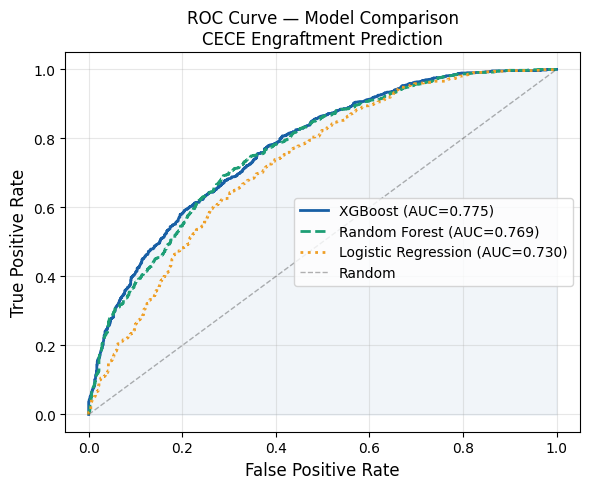

Fig_ROC.png saved


In [6]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_prob_rf  = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf  = rf_model.predict(X_test)
auc_rf     = roc_auc_score(y_test, y_prob_rf)
print(f'Random Forest AUC: {auc_rf:.4f}')

print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train, y_train)
y_prob_lr  = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr  = lr_model.predict(X_test)
auc_lr     = roc_auc_score(y_test, y_prob_lr)
print(f'Logistic Regression AUC: {auc_lr:.4f}')

model_comparison = pd.DataFrame([
    {
        'Model':     'XGBoost',
        'AUC_ROC':   round(auc_full, 4),
        'Precision': round(precision_score(y_test, y_pred_full), 4),
        'Recall':    round(recall_score(y_test, y_pred_full), 4),
        'F1':        round(f1_score(y_test, y_pred_full), 4),
        'Reference': 'Grinsztajn et al. 2022 NeurIPS'
    },
    {
        'Model':     'Random Forest',
        'AUC_ROC':   round(auc_rf, 4),
        'Precision': round(precision_score(y_test, y_pred_rf), 4),
        'Recall':    round(recall_score(y_test, y_pred_rf), 4),
        'F1':        round(f1_score(y_test, y_pred_rf), 4),
        'Reference': 'Breiman 2001 Machine Learning'
    },
    {
        'Model':     'Logistic Regression',
        'AUC_ROC':   round(auc_lr, 4),
        'Precision': round(precision_score(y_test, y_pred_lr), 4),
        'Recall':    round(recall_score(y_test, y_pred_lr), 4),
        'F1':        round(f1_score(y_test, y_pred_lr), 4),
        'Reference': 'Baseline'
    },
])

model_comparison.to_csv('../results/Table_model_comparison.csv', index=False)

print('\nModel Comparison:')
print(model_comparison[['Model','AUC_ROC','Precision','Recall','F1']].to_string(index=False))

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_full)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(fpr_xgb, tpr_xgb, '#185FA5', lw=2,
        label=f'XGBoost (AUC={auc_full:.3f})')
ax.plot(fpr_rf,  tpr_rf,  '#1D9E75', lw=2, linestyle='--',
        label=f'Random Forest (AUC={auc_rf:.3f})')
ax.plot(fpr_lr,  tpr_lr,  '#EF9F27', lw=2, linestyle=':',
        label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.3, label='Random')

ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.06, color='#185FA5')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Model Comparison\nCECE Engraftment Prediction', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/final/Fig_ROC.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig_ROC.png saved')

In [7]:
ablation_results = [{
    'removed_group': 'none (full model)',
    'n_features':    len(ALL_FEATURES),
    'AUC':           round(auc_full, 4),
    'F1':            round(f1_score(y_test, y_pred_full), 4),
    'delta_AUC':     0.0
}]

print('Ablation — removing one group at a time:\n')

for group_name, group_cols in FEATURE_GROUPS.items():
    available = [c for c in group_cols if c in ALL_FEATURES]
    if not available:
        continue
    remaining = [f for f in ALL_FEATURES if f not in available]
    if len(remaining) < 2:
        continue

    model_abl = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', use_label_encoder=False,
        random_state=42
    )
    model_abl.fit(
        X_train[remaining], y_train,
        eval_set=[(X_test[remaining], y_test)],
        verbose=False
    )
    y_prob_abl = model_abl.predict_proba(X_test[remaining])[:, 1]
    y_pred_abl = model_abl.predict(X_test[remaining])
    auc_abl    = roc_auc_score(y_test, y_prob_abl)
    delta      = auc_full - auc_abl

    ablation_results.append({
        'removed_group': group_name,
        'n_features':    len(remaining),
        'AUC':           round(auc_abl, 4),
        'F1':            round(f1_score(y_test, y_pred_abl), 4),
        'delta_AUC':     round(delta, 4)
    })
    print(f'  Without {group_name:12s}: AUC={auc_abl:.4f}  '
          f'delta={delta:+.4f}  ({len(available)} features removed)')

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv('../results/Table_ablation.csv', index=False)

print('\nFull ablation table:')
print(ablation_df.to_string(index=False))

Ablation — removing one group at a time:

  Without ecological  : AUC=0.7743  delta=+0.0008  (2 features removed)
  Without causal      : AUC=0.7545  delta=+0.0206  (3 features removed)
  Without metabolic   : AUC=0.7751  delta=-0.0000  (2 features removed)
  Without scfa        : AUC=0.7756  delta=-0.0005  (7 features removed)
  Without donor       : AUC=0.7493  delta=+0.0258  (1 features removed)

Full ablation table:
    removed_group  n_features    AUC     F1  delta_AUC
none (full model)          15 0.7751 0.7180     0.0000
       ecological          13 0.7743 0.7178     0.0008
           causal          12 0.7545 0.6952     0.0206
        metabolic          13 0.7751 0.7210    -0.0000
             scfa           8 0.7756 0.7198    -0.0005
            donor          14 0.7493 0.6933     0.0258


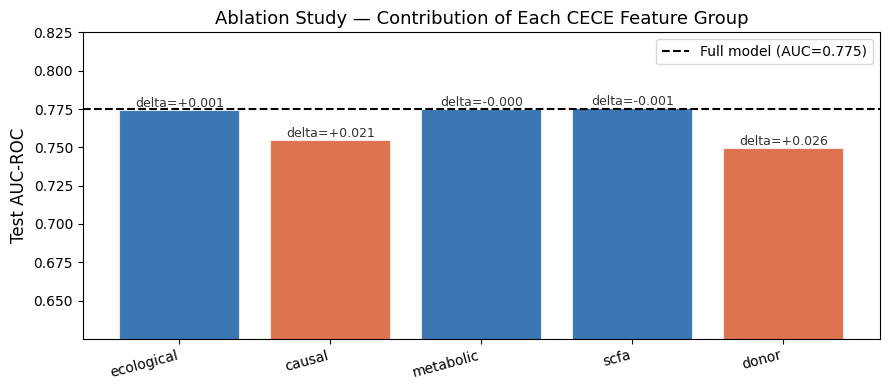

Fig_ablation.png saved


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

abl_plot = ablation_df[
    ablation_df['removed_group'] != 'none (full model)'
].copy()

bar_colors = [
    '#D85A30' if d > 0.02 else
    '#EF9F27' if d > 0.005 else
    '#185FA5'
    for d in abl_plot['delta_AUC']
]

bars = ax.bar(
    abl_plot['removed_group'], abl_plot['AUC'],
    color=bar_colors, alpha=0.85,
    edgecolor='white', linewidth=1.5
)

ax.axhline(auc_full, color='black', linestyle='--', linewidth=1.5,
           label=f'Full model (AUC={auc_full:.3f})')

ax.set_ylabel('Test AUC-ROC', fontsize=12)
ax.set_title('Ablation Study — Contribution of Each CECE Feature Group',
             fontsize=13)
ax.set_ylim(max(0.45, auc_full - 0.15), min(1.0, auc_full + 0.05))
ax.legend(fontsize=10)

for bar, (_, row) in zip(bars, abl_plot.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'delta={row["delta_AUC"]:+.3f}',
        ha='center', fontsize=9, color='#333333'
    )

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../figures/final/Fig_ablation.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig_ablation.png saved')

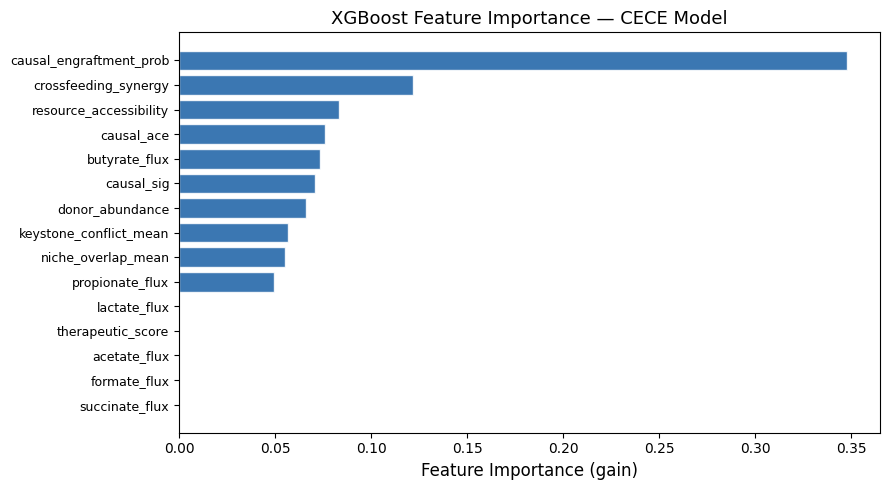

Fig_SHAP.png saved


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    'feature':    ALL_FEATURES,
    'importance': model_full.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.barh(importance['feature'], importance['importance'],
        color='#185FA5', alpha=0.85, edgecolor='white')
ax.set_xlabel('Feature Importance (gain)', fontsize=12)
ax.set_title('XGBoost Feature Importance — CECE Model', fontsize=13)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('../figures/final/Fig_SHAP.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Fig_SHAP.png saved')

In [13]:
import joblib

joblib.dump(model_full, '../results/cece_xgb_model.pkl')
print('XGBoost model saved: results/cece_xgb_model.pkl')

table1 = pd.DataFrame([{
    'AUC_ROC':         round(auc_full, 4),
    'Precision':       round(precision_score(y_test, y_pred_full), 4),
    'Recall':          round(recall_score(y_test, y_pred_full), 4),
    'F1':              round(f1_score(y_test, y_pred_full), 4),
    'Model':           'XGBoost',
    'N_features':      len(ALL_FEATURES),
    'N_test_records':  len(y_test),
    'N_test_species':  test_df['species'].nunique(),
    'N_train_records': len(y_train),
    'N_train_species': train_df['species'].nunique(),
}])

table1.to_csv('../results/Table1_model_performance.csv', index=False)

print('\nTable 1 — Primary Model Performance (XGBoost):')
print(table1.to_string(index=False))

print('\nModel comparison (Table S1):')
comp = pd.read_csv('../results/Table_model_comparison.csv')
print(comp[['Model','AUC_ROC','F1']].to_string(index=False))

XGBoost model saved: results/cece_xgb_model.pkl

Table 1 — Primary Model Performance (XGBoost):
 AUC_ROC  Precision  Recall    F1   Model  N_features  N_test_records  N_test_species  N_train_records  N_train_species
  0.7751      0.682  0.7581 0.718 XGBoost          15            2229             205             8722              266

Model comparison (Table S1):
              Model  AUC_ROC     F1
            XGBoost   0.7751 0.7180
      Random Forest   0.7686 0.7172
Logistic Regression   0.7298 0.6920
